## Prediksi Multi-Hari Konsentrasi NO₂ Menggunakan Model KNN Regression

Pada tugas kali ini bertujuan untuk memprediksi konsentrasi gas Nitrogen Dioksida (NO₂) selama beberapa hari ke depan menggunakan metode K-Nearest Neighbors (KNN) Regression. Lokasi pengamatan yang digunakan berada di sekitar Kamal–Labang, Bangkalan, Madura, dengan data yang bersumber dari Sentinel-5P (Copernicus Data Space).
Model ini dilatih menggunakan data periode Juli 2021 hingga Juli 2022, kemudian digunakan untuk memprediksi nilai NO₂ hingga tiga hari ke depan berdasarkan data historis tiga hari sebelumnya.
Hasil prediksi juga dievaluasi terhadap batas ambang kualitas udara menurut standar WHO, guna mengetahui apakah konsentrasi gas NO₂ masih dalam kategori aman, perlu perhatian, atau berbahaya.

### Install OpenEo

In [2]:
pip install openeo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [openeo]]  WARNING: The script openeo-auth is installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [openeo]
Note: you may need to restart the kernel to use updated packages.


### Import Library

In [1]:
import openeo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, ConfusionMatrixDisplay
)

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Semua library berhasil diimport")

Semua library berhasil diimport


## Data UnderStanding

### 1.Pengumpulan Data 
Dimana bersumber dari Sentinel-5p via OpenEo (Copernicus Data Space), dan untuk outputnya adalah sebuah file csv dengan data No2 harian untuk periode Juli 2021-Juli 2022.

In [3]:
import openeo
import pandas as pd
import os
import time

print("="*75)
print("LANGKAH 1: PENGUMPULAN DATA NO2 (Sentinel-5P via OpenEO)")
print("="*75)

# 1. Koneksi ke Copernicus Data Space
print("Menghubungkan ke OpenEO DataSpace...")
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print("Koneksi berhasil.\n")

# 2. Area of Interest (AOI) - Bangkalan, Madura
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [112.72039971871624, -7.11744614362911],
        [112.72039971871624, -7.156335253461791],
        [112.78220716761746, -7.156335253461791],
        [112.78220716761746, -7.11744614362911],
        [112.72039971871624, -7.11744614362911],
    ]]
}

# 3. Load data Sentinel-5P
print("Mengambil data Sentinel-5P (band: NO2)...")
s5p = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent={
        "west": 112.72039971871624,
        "south": -7.156335253461791,
        "east": 112.78220716761746,
        "north": -7.11744614362911,
    },
    temporal_extent=["2021-07-01", "2022-07-30"],
    bands=["NO2"],
)

# 4. Mask nilai negatif
def mask_invalid(x):
    return x < 0

s5p_masked = s5p.mask(s5p.apply(mask_invalid))
print("Nilai negatif berhasil dimasking.")

# 5. Agregasi temporal (harian)
daily_mean = s5p_masked.aggregate_temporal_period(period="day", reducer="mean")

# 6. Agregasi spasial (mean dalam AOI)
daily_mean_aoi = daily_mean.aggregate_spatial(geometries=aoi, reducer="mean")
print("Agregasi spasial dan temporal selesai.")

# 7. Jalankan batch job
print("\nMenjalankan batch job di OpenEO...")
job = daily_mean_aoi.create_job(out_format="CSV")
job.start()

print(f"Job berhasil dikirim (Job ID: {job.job_id})")
print("Menunggu job selesai (pengecekan setiap 2 menit)...")

# 8. Monitoring job status
while True:
    status = job.describe()["status"]
    print(f"Status saat ini: {status}")
    if status == "finished":
        print("Job selesai. Mengunduh hasil...")
        break
    elif status == "error":
        raise RuntimeError("Job gagal di server OpenEO.")
    time.sleep(120)  # cek setiap 2 menit

# 9. Unduh hasil
os.makedirs("no2_results", exist_ok=True)
results = job.get_results()
results.download_files("no2_results")

# 10. Baca hasil CSV
csv_files = [f for f in os.listdir("no2_results") if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("Tidak ada file CSV ditemukan di folder hasil.")

df = pd.read_csv(os.path.join("no2_results", csv_files[0]))

# 11. Preprocessing data
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.to_csv("timeseries.csv", index=False)

# 12. Ringkasan hasil
print("\nDATA BERHASIL DIKUMPULKAN")
print("-" * 60)
print(f"Periode        : {df['date'].min().date()} - {df['date'].max().date()}")
print(f"Total records  : {len(df)}")
print(f"File output    : timeseries.csv")
print("-" * 60)
print("\nData pertama (5 baris):")
print(df.head())


LANGKAH 1: PENGUMPULAN DATA NO2 (Sentinel-5P via OpenEO)
Menghubungkan ke OpenEO DataSpace...
Authenticated using refresh token.
Koneksi berhasil.

Mengambil data Sentinel-5P (band: NO2)...
Nilai negatif berhasil dimasking.
Agregasi spasial dan temporal selesai.

Menjalankan batch job di OpenEO...
Job berhasil dikirim (Job ID: j-251101010403484dbe42dc0ad7387951)
Menunggu job selesai (pengecekan setiap 2 menit)...
Status saat ini: queued
Status saat ini: running
Status saat ini: running
Status saat ini: running
Status saat ini: finished
Job selesai. Mengunduh hasil...

DATA BERHASIL DIKUMPULKAN
------------------------------------------------------------
Periode        : 2021-06-30 - 2022-07-29
Total records  : 395
File output    : timeseries.csv
------------------------------------------------------------

Data pertama (5 baris):
                       date  feature_index       NO2
0 2021-06-30 00:00:00+00:00              0       NaN
1 2021-07-01 00:00:00+00:00              0  0.000041

Total records : 395
Periode data  : 2021-06-30 hingga 2022-07-29


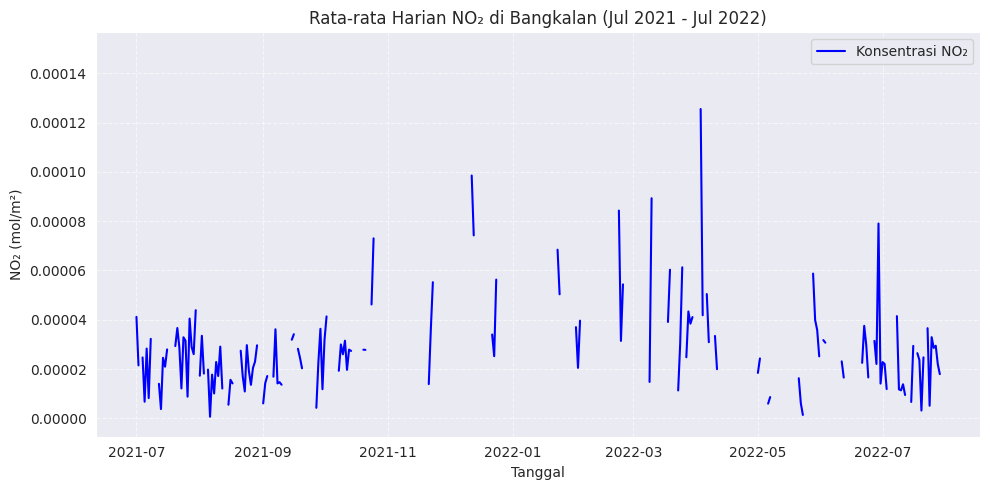

In [2]:
# Baca hasil dari file yang sudah kamu dapat sebelumnya
df = pd.read_csv("timeseries.csv")

# Konversi tanggal
df["date"] = pd.to_datetime(df["date"])

# Hitung total records (jumlah sample)
total_records = len(df)

# Tampilkan informasi di console
print(f"Total records : {total_records}")
print(f"Periode data  : {df['date'].min().date()} hingga {df['date'].max().date()}")

# Plot sederhana
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["NO2"], color="blue", label="Konsentrasi NO₂")
plt.xlabel("Tanggal")
plt.ylabel("NO₂ (mol/m²)")
plt.title("Rata-rata Harian NO₂ di Bangkalan (Jul 2021 - Jul 2022)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Note: Karena pada saat di deploy itu kode bagian yang langsung terkoneksi ke OpenEo itu runtime  karena program memang terjebak di bagian while True: yang menunggu job OpenEO selesai — dan prosesnya memang bisa lama (kadang 10–30 menit, tergantung luas area dan periode waktu). saat di deploy di github maka saya menambahkan kode ke dua yang langsung membaca pada data csv yang dihasilkan. berikut bukti bahwa kode saya memang berhasil. 
![Bukti NO2](images/bukti.png)



## Data Preparation
Tahap persiapan data untuk machine learning:

- Missing Values: Interpolasi linear

- Supervised Learning: Membuat lag features

- Train-Test Split: 80-20 split

- Normalisasi: MinMaxScaler untuk KNN

### 2. Prepocessing-Missing Value


----------------------------------------------------------------------
LANGKAH 2: PROSES PREPROCESSING DATA (INTERPOLASI NILAI HILANG)
----------------------------------------------------------------------

Jumlah nilai hilang sebelum interpolasi: 215 (54.43%)
Jumlah nilai hilang sesudah interpolasi: 0

Statistik deskriptif nilai NO₂ setelah proses interpolasi:
count    3.950000e+02
mean     3.648103e-05
std      2.537001e-05
min      2.094412e-08
25%      1.911616e-05
50%      2.870651e-05
75%      4.693880e-05
max      1.491192e-04
Name: NO2, dtype: float64


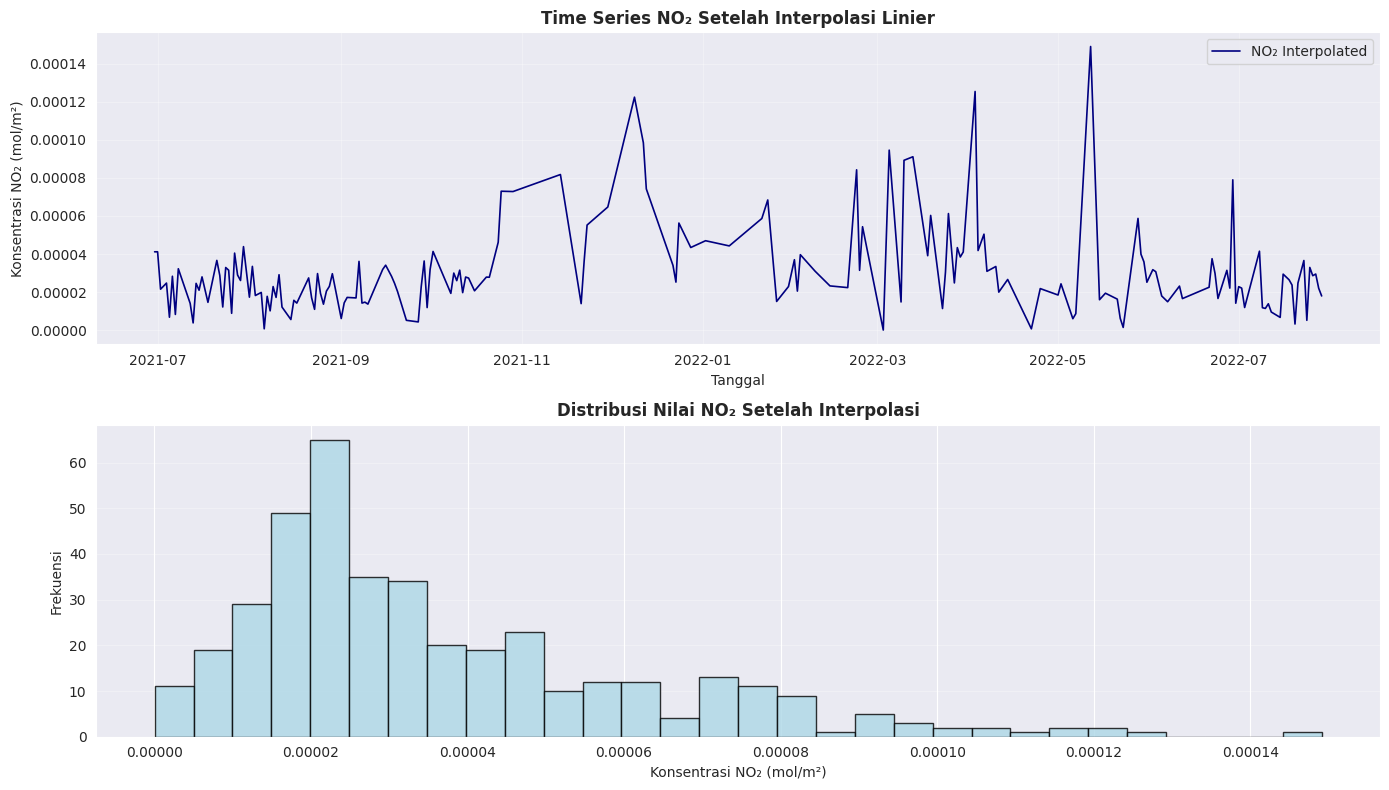


 Proses preprocessing selesai dengan sukses!


In [3]:
# ======================== LANGKAH 2: PREPROCESSING - INTERPOLASI ==========================
print("\n" + "-"*70)
print("LANGKAH 2: PROSES PREPROCESSING DATA (INTERPOLASI NILAI HILANG)")
print("-"*70)

# Membaca dataset
data = pd.read_csv("timeseries.csv")
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(by="date").reset_index(drop=True)

# Mengecek jumlah nilai hilang sebelum interpolasi
n_missing_before = data["NO2"].isnull().sum()
persen_missing = (n_missing_before / len(data)) * 100
print(f"\nJumlah nilai hilang sebelum interpolasi: {n_missing_before} ({persen_missing:.2f}%)")

# Melakukan interpolasi linier dan pengisian nilai ujung
data["NO2"] = data["NO2"].interpolate(method="linear")
data["NO2"].fillna(method="ffill", inplace=True)
data["NO2"].fillna(method="bfill", inplace=True)

# Mengecek nilai hilang setelah interpolasi
n_missing_after = data["NO2"].isnull().sum()
print(f"Jumlah nilai hilang sesudah interpolasi: {n_missing_after}")

# Menampilkan ringkasan statistik
print("\nStatistik deskriptif nilai NO₂ setelah proses interpolasi:")
print(data["NO2"].describe())

# ============================ VISUALISASI HASIL INTERPOLASI ==============================
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(14, 8))

# Plot time series
ax1.plot(data["date"], data["NO2"], color="navy", linewidth=1.2, label="NO₂ Interpolated")
ax1.set_title("Time Series NO₂ Setelah Interpolasi Linier", fontsize=12, fontweight="bold")
ax1.set_xlabel("Tanggal")
ax1.set_ylabel("Konsentrasi NO₂ (mol/m²)")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot distribusi
ax2.hist(data["NO2"], bins=30, color="lightblue", edgecolor="black", alpha=0.8)
ax2.set_title("Distribusi Nilai NO₂ Setelah Interpolasi", fontsize=12, fontweight="bold")
ax2.set_xlabel("Konsentrasi NO₂ (mol/m²)")
ax2.set_ylabel("Frekuensi")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Proses preprocessing selesai dengan sukses!")


### 3. Transformasi ke Supervised Learning

In [4]:
# ======================= LANGKAH 3: KONVERSI KE SUPERVISED LEARNING =======================
print("\n" + "-"*70)
print("LANGKAH 3: TRANSFORMASI DATA TIME SERIES KE MODEL SUPERVISED LEARNING")
print("-"*70)

def convert_to_supervised(dataset, n_past=1, n_future=1, remove_na=True):
    """
    Mengubah data deret waktu (time series) menjadi format supervised learning.
    Contoh: memprediksi NO2(t) berdasarkan NO2(t-1), NO2(t-2), dst.
    """
    df_temp = pd.DataFrame(dataset)
    frame_list, col_labels = [], []

    # Membuat kolom input (lag)
    for step in range(n_past, 0, -1):
        frame_list.append(df_temp.shift(step))
        col_labels.append(f"NO2(t-{step})")

    # Membuat kolom output (nilai target)
    for step in range(0, n_future):
        frame_list.append(df_temp.shift(-step))
        if step == 0:
            col_labels.append("NO2(t)")
        else:
            col_labels.append(f"NO2(t+{step})")

    # Gabungkan semua kolom
    merged = pd.concat(frame_list, axis=1)
    merged.columns = col_labels

    # Hapus baris dengan nilai NaN (karena hasil pergeseran)
    if remove_na:
        merged.dropna(inplace=True)

    return merged

# Gunakan 3 lag (t-1, t-2, t-3)
lag_count = 3
supervised_data = convert_to_supervised(data[["NO2"]], n_past=lag_count, n_future=1)

print(f"\nData berhasil diubah menjadi format supervised learning dengan lag = {lag_count}")
print(f"  • Total sampel : {len(supervised_data)}")
print(f"  • Jumlah fitur : {lag_count} (dari t-1 sampai t-{lag_count})")
print(f"  • Jumlah target: 1 (yaitu NO2(t))")
print("\nContoh 5 data pertama:")
print(supervised_data.head())


----------------------------------------------------------------------
LANGKAH 3: TRANSFORMASI DATA TIME SERIES KE MODEL SUPERVISED LEARNING
----------------------------------------------------------------------

Data berhasil diubah menjadi format supervised learning dengan lag = 3
  • Total sampel : 392
  • Jumlah fitur : 3 (dari t-1 sampai t-3)
  • Jumlah target: 1 (yaitu NO2(t))

Contoh 5 data pertama:
   NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
3  0.000041  0.000041  0.000021  0.000023
4  0.000041  0.000021  0.000023  0.000025
5  0.000021  0.000023  0.000025  0.000007
6  0.000023  0.000025  0.000007  0.000028
7  0.000025  0.000007  0.000028  0.000008


### 4. TRAIN-TEST SPLIT (80:20)


----------------------------------------------------------------------
LANGKAH 4A: PEMBAGIAN DATA TRAIN-TEST (80:20)
----------------------------------------------------------------------

Jumlah data training : 313 sampel
Jumlah data testing  : 79 sampel


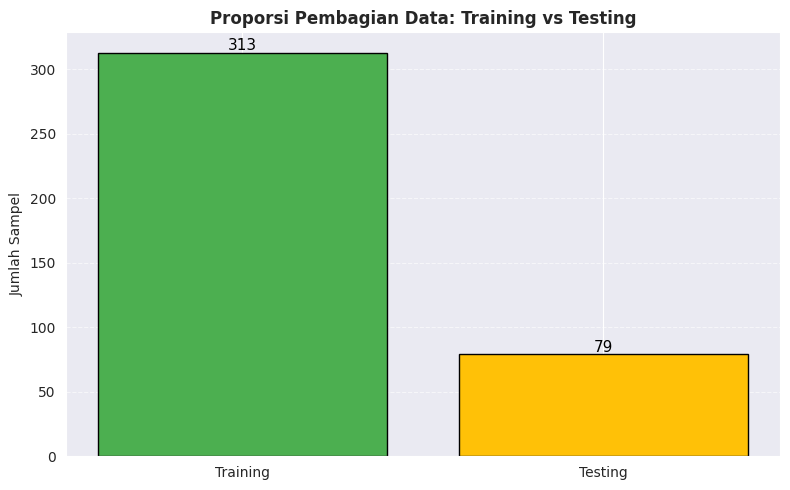

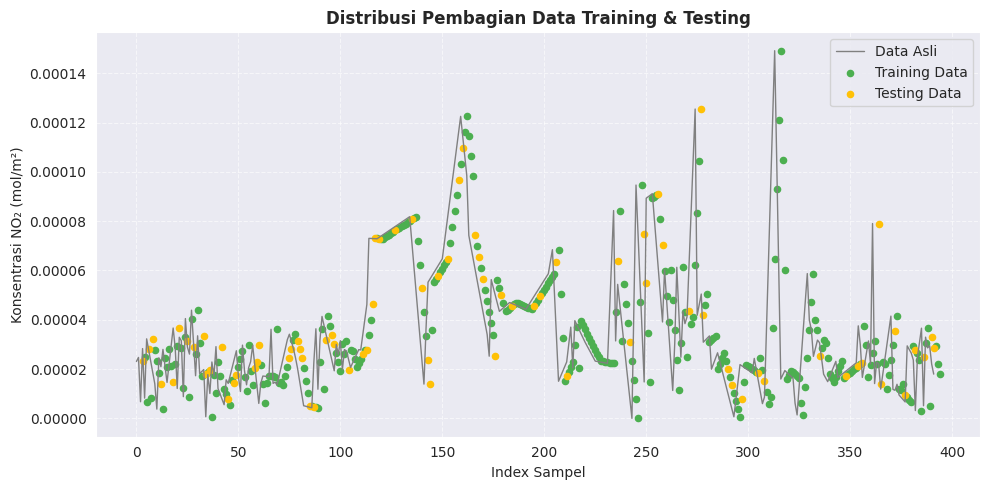

In [5]:
# ======================= LANGKAH 4A: TRAIN-TEST SPLIT (80:20) =======================
print("\n" + "-"*70)
print("LANGKAH 4A: PEMBAGIAN DATA TRAIN-TEST (80:20)")
print("-"*70)

# Pisahkan fitur (X) dan target (y)
X = supervised_data.iloc[:, :-1]   # Fitur (NO2(t-1), NO2(t-2), NO2(t-3))
y = supervised_data.iloc[:, -1]    # Target (NO2(t))

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"\nJumlah data training : {len(X_train)} sampel")
print(f"Jumlah data testing  : {len(X_test)} sampel")

# Plot perbandingan jumlah data train dan test
plt.figure(figsize=(8, 5))
bars = plt.bar(["Training", "Testing"], [len(X_train), len(X_test)], color=["#4CAF50", "#FFC107"], edgecolor="black")
plt.title("Proporsi Pembagian Data: Training vs Testing", fontsize=12, fontweight="bold")
plt.ylabel("Jumlah Sampel")
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5, str(bar.get_height()), 
             ha='center', va='bottom', fontsize=11, color="black")
plt.tight_layout()
plt.show()

# Plot sebaran data (train vs test)
plt.figure(figsize=(10, 5))
plt.plot(y.values, label="Data Asli", color="gray", linewidth=1)
plt.scatter(y_train.index, y_train.values, color="#4CAF50", label="Training Data", s=20)
plt.scatter(y_test.index, y_test.values, color="#FFC107", label="Testing Data", s=20)
plt.title("Distribusi Pembagian Data Training & Testing", fontsize=12, fontweight="bold")
plt.xlabel("Index Sampel")
plt.ylabel("Konsentrasi NO₂ (mol/m²)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### 5. NORMALISASI (MINMAXSCALER)


----------------------------------------------------------------------
LANGKAH 4B: NORMALISASI DATA MENGGUNAKAN MINMAXSCALER
----------------------------------------------------------------------

Contoh hasil normalisasi data training:
   NO2(t-3)  NO2(t-2)  NO2(t-1)
0  0.469315  0.401772  0.331969
1  0.292851  0.300654  0.305446
2  0.314997  0.287954  0.257994
3  0.036505  0.095808  0.115073
4  0.116412  0.110010  0.099845


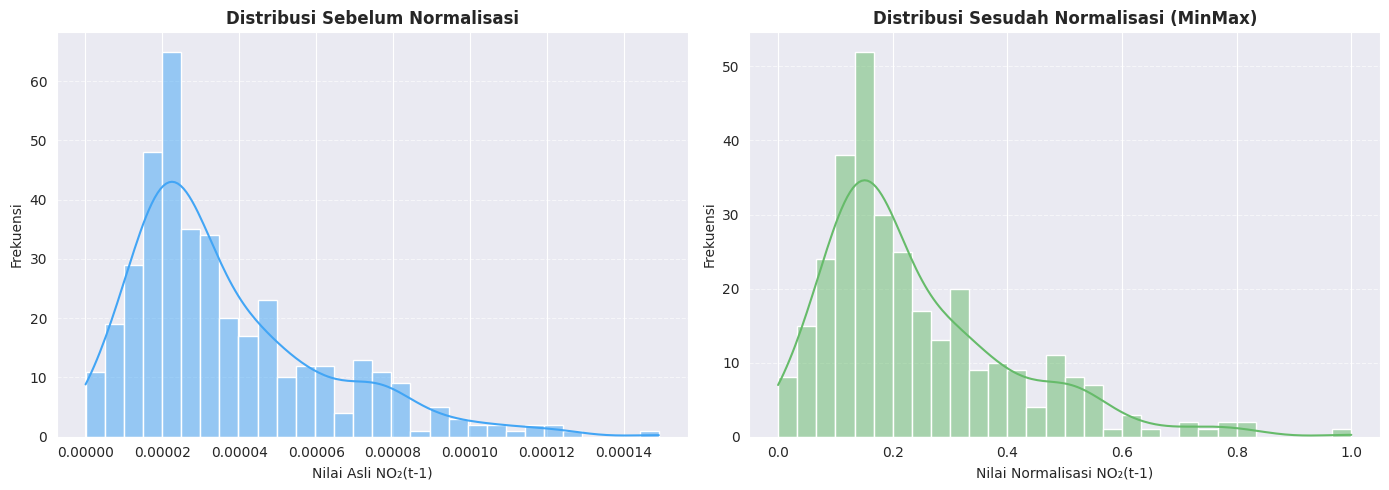

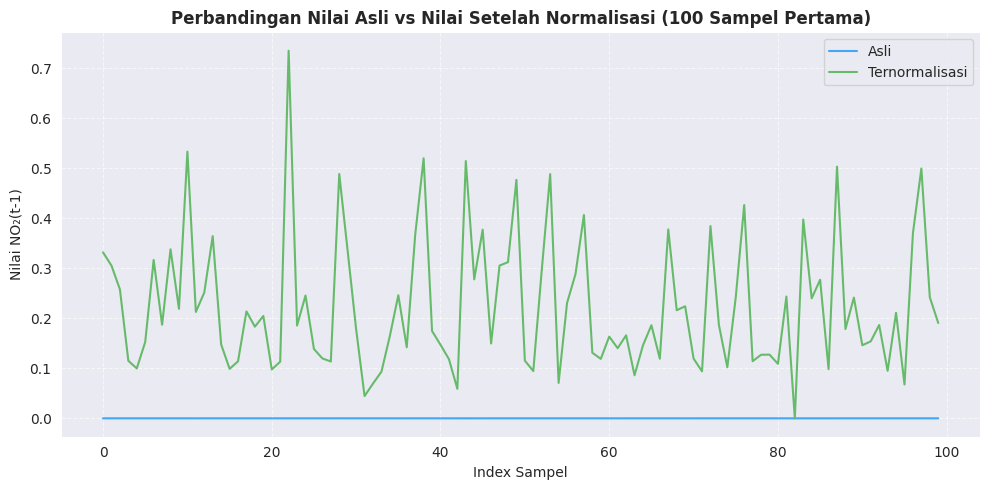

In [6]:
# ======================= LANGKAH 4B: NORMALISASI DENGAN MINMAXSCALER =======================
print("\n" + "-"*70)
print("LANGKAH 4B: NORMALISASI DATA MENGGUNAKAN MINMAXSCALER")
print("-"*70)

# Normalisasi fitur agar berada dalam rentang [0, 1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi ke DataFrame agar mudah dibaca
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nContoh hasil normalisasi data training:")
print(X_train_scaled_df.head())

# ===== Plot distribusi sebelum & sesudah normalisasi =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum normalisasi
sns.histplot(X["NO2(t-1)"], bins=30, color="#42A5F5", ax=axes[0], kde=True)
axes[0].set_title("Distribusi Sebelum Normalisasi", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nilai Asli NO₂(t-1)")
axes[0].set_ylabel("Frekuensi")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Sesudah normalisasi
sns.histplot(X_train_scaled_df["NO2(t-1)"], bins=30, color="#66BB6A", ax=axes[1], kde=True)
axes[1].set_title("Distribusi Sesudah Normalisasi (MinMax)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Nilai Normalisasi NO₂(t-1)")
axes[1].set_ylabel("Frekuensi")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ===== Plot perbandingan nilai asli vs hasil normalisasi =====
plt.figure(figsize=(10, 5))
plt.plot(X["NO2(t-1)"].values[:100], label="Asli", color="#42A5F5")
plt.plot(X_train_scaled_df["NO2(t-1)"].values[:100], label="Ternormalisasi", color="#66BB6A")
plt.title("Perbandingan Nilai Asli vs Nilai Setelah Normalisasi (100 Sampel Pertama)", fontsize=12, fontweight="bold")
plt.xlabel("Index Sampel")
plt.ylabel("Nilai NO₂(t-1)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Modelling
Pada tahap ini, model KNN Regression dikembangkan untuk memprediksi konsentrasi NO₂ berdasarkan pola historis.

- Training: Beberapa percobaan dilakukan dengan nilai K yang berbeda untuk menentukan konfigurasi paling optimal.

- Evaluasi: Hasil model dinilai menggunakan metrik regresi dan dibandingkan dengan standar WHO untuk memastikan keakuratan serta relevansi lingkungan.

- Deployment: Setelah model menunjukkan performa terbaik, model tersebut diterapkan untuk melakukan prediksi pada data baru.

### 6. Pemodelan KNN Regression


 LANGKAH 6: PEMODELAN KNN REGRESSION 

---------------------------------------------------------------------------
  UJI COBA: VARIASI NILAI K PADA KNN REGRESSION
---------------------------------------------------------------------------
  ➤ K=2  | RMSE=0.00001912 | MAE=0.00001182 | MAPE=40.37% | R²=0.4242
  ➤ K=3  | RMSE=0.00001828 | MAE=0.00001116 | MAPE=40.56% | R²=0.4735
  ➤ K=5  | RMSE=0.00001757 | MAE=0.00001058 | MAPE=38.64% | R²=0.5138
  ➤ K=7  | RMSE=0.00001633 | MAE=0.00000970 | MAPE=34.29% | R²=0.5801
  ➤ K=9  | RMSE=0.00001571 | MAE=0.00000941 | MAPE=34.09% | R²=0.6110
  ➤ K=11 | RMSE=0.00001536 | MAE=0.00000942 | MAPE=33.86% | R²=0.6284

 Hasil Terbaik:
  • K optimal      : 11
  • RMSE terkecil  : 0.00001536
  • MAPE            : 33.86%
  • R² Score       : 0.6284


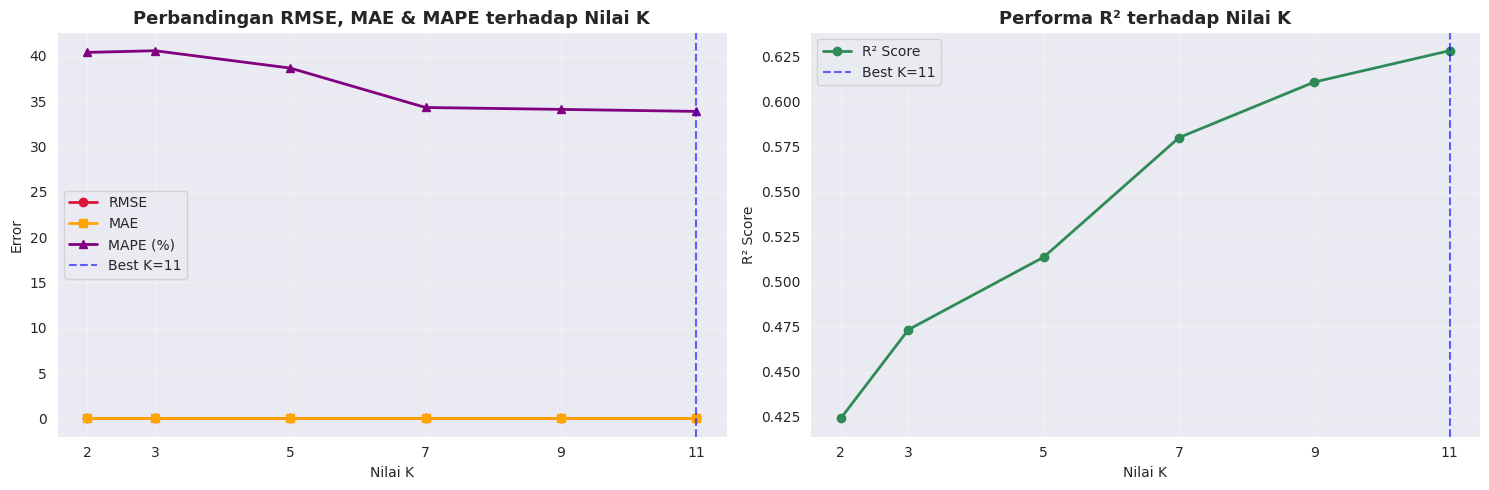


Menampilkan hasil prediksi terbaik dengan K = 11...


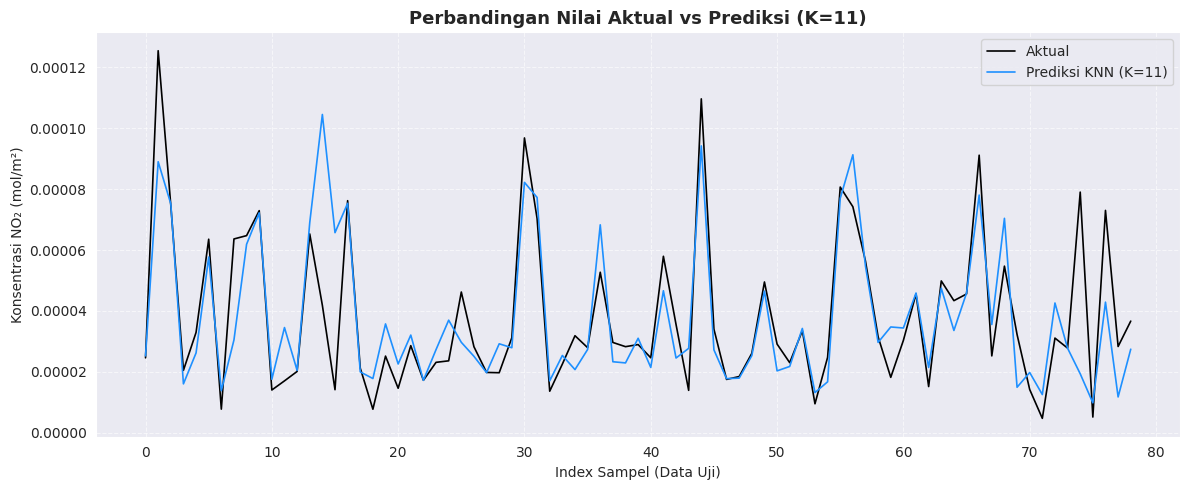


 Proses KNN Regression selesai! Model terbaik menggunakan K = 11


In [7]:
# ======================= LANGKAH 6: PEMODELAN KNN REGRESSION =======================
print("\n" + "="*75)
print(" LANGKAH 6: PEMODELAN KNN REGRESSION ")
print("="*75)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ========================== EKSPERIMEN NILAI K ==========================
k_values = [2, 3, 5, 7, 9, 11]
print("\n" + "-"*75)
print("  UJI COBA: VARIASI NILAI K PADA KNN REGRESSION")
print("-"*75)

results_k = []
for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn_model.fit(X_train_scaled, y_train)
    y_pred = knn_model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error

    results_k.append({
        'K': k,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R²': r2
    })

    print(f"  ➤ K={k:<2d} | RMSE={rmse:.8f} | MAE={mae:.8f} | MAPE={mape:.2f}% | R²={r2:.4f}")

# Simpan hasil ke DataFrame
results_k_df = pd.DataFrame(results_k)

# Tentukan K terbaik (berdasarkan RMSE terkecil)
best_idx = results_k_df['RMSE'].idxmin()
best_k = int(results_k_df.loc[best_idx, 'K'])
best_rmse = results_k_df.loc[best_idx, 'RMSE']
best_r2 = results_k_df.loc[best_idx, 'R²']
best_mape = results_k_df.loc[best_idx, 'MAPE (%)']

print("\n Hasil Terbaik:")
print(f"  • K optimal      : {best_k}")
print(f"  • RMSE terkecil  : {best_rmse:.8f}")
print(f"  • MAPE            : {best_mape:.2f}%")
print(f"  • R² Score       : {best_r2:.4f}")

# ========================== VISUALISASI PERFORMA MODEL ==========================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot RMSE, MAE, MAPE
axes[0].plot(results_k_df['K'], results_k_df['RMSE'], 'o-', lw=2, color='crimson', label='RMSE')
axes[0].plot(results_k_df['K'], results_k_df['MAE'], 's-', lw=2, color='orange', label='MAE')
axes[0].plot(results_k_df['K'], results_k_df['MAPE (%)'], '^-', lw=2, color='purple', label='MAPE (%)')
axes[0].axvline(best_k, color='blue', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
axes[0].set_title('Perbandingan RMSE, MAE & MAPE terhadap Nilai K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nilai K')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(k_values)

# Plot R²
axes[1].plot(results_k_df['K'], results_k_df['R²'], 'o-', lw=2, color='seagreen', label='R² Score')
axes[1].axvline(best_k, color='blue', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
axes[1].set_title('Performa R² terhadap Nilai K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nilai K')
axes[1].set_ylabel('R² Score')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

# ========================== VISUALISASI PREDIKSI TERBAIK ==========================
print(f"\nMenampilkan hasil prediksi terbaik dengan K = {best_k}...")

# Fit ulang model dengan K terbaik
best_model = KNeighborsRegressor(n_neighbors=best_k, metric='euclidean')
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

# Plot hasil aktual vs prediksi
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Aktual", color='black', linewidth=1.2)
plt.plot(y_pred_best, label=f"Prediksi KNN (K={best_k})", color='dodgerblue', linewidth=1.2)
plt.title(f"Perbandingan Nilai Aktual vs Prediksi (K={best_k})", fontsize=13, fontweight='bold')
plt.xlabel("Index Sampel (Data Uji)")
plt.ylabel("Konsentrasi NO₂ (mol/m²)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n Proses KNN Regression selesai! Model terbaik menggunakan K = {best_k}")


### 7. Evaluasi Model & Standar WHO


LANGKAH 7: EVALUASI REGRESI KNN BERDASARKAN METRIK & STANDAR WHO

✓ Model akhir berhasil disimpan di: model_knn_regression.pkl
  → Model ini siap digunakan untuk prediksi data baru (deployment stage)

[A] HASIL EVALUASI MODEL (K = 11)
  • Mean Squared Error (MSE)  : 0.0000000002
  • Root Mean Squared Error   : 0.0000153591
  • Mean Absolute Error (MAE) : 0.0000094191
  • Mean Absolute Percentage Error (MAPE): 33.86%
  • Koefisien Determinasi (R²): 0.6284

[INTERPRETASI MAPE]
  ⚠ Akurasi CUKUP (Reasonable Prediction)

[B] ANALISIS KONVERSI DAN STANDAR WHO
  • Faktor konversi ke µg/m³ : 46010
  • Rentang data aktual      : [0.22, 5.77] µg/m³
  • Rentang hasil prediksi   : [0.45, 4.81] µg/m³

[C] PERBANDINGAN TERHADAP BATAS WHO
  → Data Aktual:
     - Di atas WHO Annual (10 µg/m³): 0/79 sampel (0.0%)
     - Di atas WHO 24-Hour (25 µg/m³): 0/79 sampel (0.0%)
  → Data Prediksi:
     - Di atas WHO Annual (10 µg/m³): 0/79 sampel (0.0%)
     - Di atas WHO 24-Hour (25 µg/m³): 0/79 sampel (0.0%

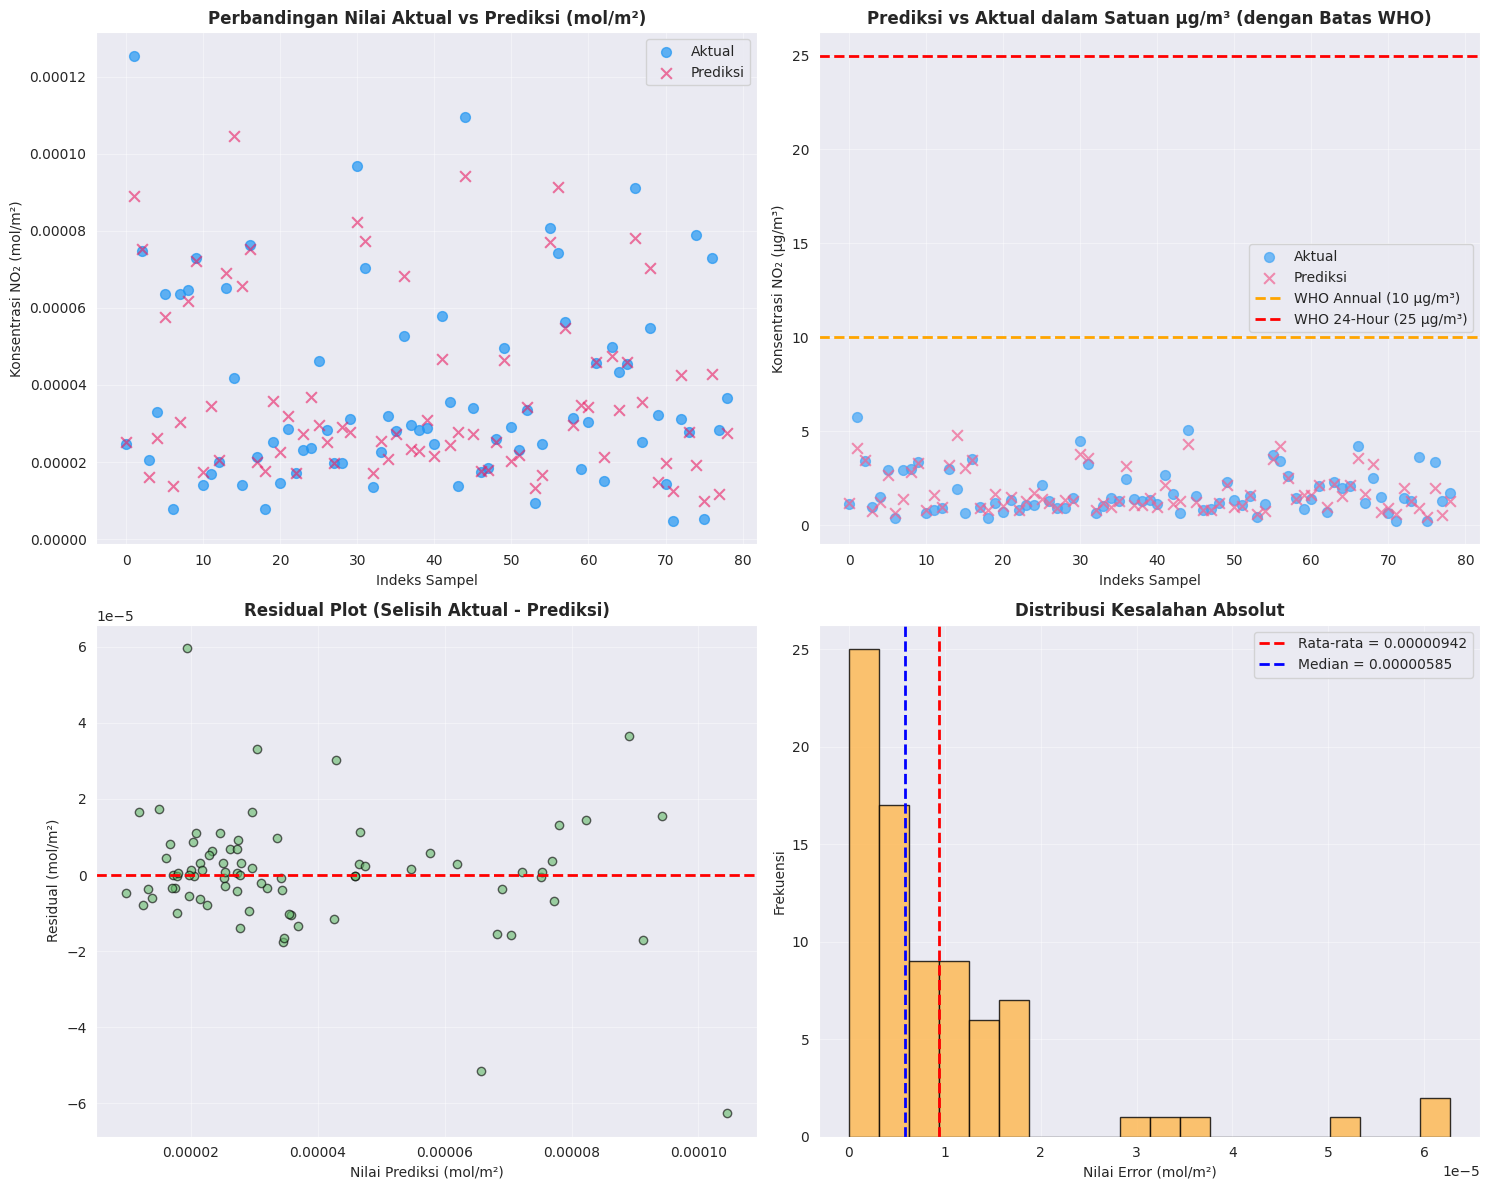


✓ Evaluasi performa dan visualisasi KNN Regression selesai.


In [8]:
# ========================== LANGKAH 7: EVALUASI MODEL & STANDAR WHO ==========================
print("\n" + "=" * 80)
print("LANGKAH 7: EVALUASI REGRESI KNN BERDASARKAN METRIK & STANDAR WHO")
print("=" * 80)

# Gunakan model terbaik berdasarkan nilai K hasil tuning sebelumnya
optimal_k = int(best_k)
knn_final = KNeighborsRegressor(n_neighbors=optimal_k, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)

# Simpan model untuk tahap deployment
model_path = "model_knn_regression.pkl"
joblib.dump(knn_final, model_path)
print(f"\n✓ Model akhir berhasil disimpan di: {model_path}")
print(f"  → Model ini siap digunakan untuk prediksi data baru (deployment stage)")

# ========================== PREDIKSI & METRIK REGRESI ==========================
y_pred_knn = knn_final.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)
mape = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100

print(f"\n[A] HASIL EVALUASI MODEL (K = {optimal_k})")
print(f"  • Mean Squared Error (MSE)  : {mse:.10f}")
print(f"  • Root Mean Squared Error   : {rmse:.10f}")
print(f"  • Mean Absolute Error (MAE) : {mae:.10f}")
print(f"  • Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"  • Koefisien Determinasi (R²): {r2:.4f}")

# Interpretasi MAPE
print("\n[INTERPRETASI MAPE]")
if mape < 10:
    print("  ✓ Akurasi SANGAT TINGGI (Highly Accurate Model)")
elif mape < 20:
    print("  ✓ Akurasi BAIK (Good Forecasting Ability)")
elif mape < 50:
    print("  ⚠ Akurasi CUKUP (Reasonable Prediction)")
else:
    print("  ✗ Akurasi RENDAH (Perlu Perbaikan Model)")

# ========================== ANALISIS STANDAR WHO ==========================
CONVERSION_FACTOR = 46010  # konversi dari mol/m² → µg/m³

y_test_ugm3 = y_test * CONVERSION_FACTOR
y_pred_ugm3 = y_pred_knn * CONVERSION_FACTOR

WHO_ANNUAL = 10   # µg/m³
WHO_24HOUR = 25   # µg/m³

print(f"\n[B] ANALISIS KONVERSI DAN STANDAR WHO")
print(f"  • Faktor konversi ke µg/m³ : {CONVERSION_FACTOR}")
print(f"  • Rentang data aktual      : [{y_test_ugm3.min():.2f}, {y_test_ugm3.max():.2f}] µg/m³")
print(f"  • Rentang hasil prediksi   : [{y_pred_ugm3.min():.2f}, {y_pred_ugm3.max():.2f}] µg/m³")

above_annual_actual = (y_test_ugm3 > WHO_ANNUAL).sum()
above_24hr_actual = (y_test_ugm3 > WHO_24HOUR).sum()
above_annual_pred = (y_pred_ugm3 > WHO_ANNUAL).sum()
above_24hr_pred = (y_pred_ugm3 > WHO_24HOUR).sum()

print(f"\n[C] PERBANDINGAN TERHADAP BATAS WHO")
print(f"  → Data Aktual:")
print(f"     - Di atas WHO Annual (10 µg/m³): {above_annual_actual}/{len(y_test)} sampel "
      f"({above_annual_actual/len(y_test)*100:.1f}%)")
print(f"     - Di atas WHO 24-Hour (25 µg/m³): {above_24hr_actual}/{len(y_test)} sampel "
      f"({above_24hr_actual/len(y_test)*100:.1f}%)")

print(f"  → Data Prediksi:")
print(f"     - Di atas WHO Annual (10 µg/m³): {above_annual_pred}/{len(y_pred_knn)} sampel "
      f"({above_annual_pred/len(y_pred_knn)*100:.1f}%)")
print(f"     - Di atas WHO 24-Hour (25 µg/m³): {above_24hr_pred}/{len(y_pred_knn)} sampel "
      f"({above_24hr_pred/len(y_pred_knn)*100:.1f}%)")

# ========================== VISUALISASI ==========================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Plot 1: Prediksi vs Aktual (mol/m²)
axes[0, 0].scatter(range(len(y_test)), y_test, label="Aktual", alpha=0.7, s=50, color="#2196F3")
axes[0, 0].scatter(range(len(y_pred_knn)), y_pred_knn, label="Prediksi", alpha=0.6, s=60, color="#E91E63", marker="x")
axes[0, 0].set_title("Perbandingan Nilai Aktual vs Prediksi (mol/m²)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Indeks Sampel")
axes[0, 0].set_ylabel("Konsentrasi NO₂ (mol/m²)")
axes[0, 0].grid(True, alpha=0.4)
axes[0, 0].legend()

# Plot 2: Prediksi vs Aktual dengan Standar WHO (µg/m³)
axes[0, 1].scatter(range(len(y_test_ugm3)), y_test_ugm3, label="Aktual", color="#42A5F5", s=50, alpha=0.7)
axes[0, 1].scatter(range(len(y_pred_ugm3)), y_pred_ugm3, label="Prediksi", color="#F06292", s=60, marker="x", alpha=0.7)
axes[0, 1].axhline(WHO_ANNUAL, color="orange", linestyle="--", linewidth=2, label=f"WHO Annual ({WHO_ANNUAL} µg/m³)")
axes[0, 1].axhline(WHO_24HOUR, color="red", linestyle="--", linewidth=2, label=f"WHO 24-Hour ({WHO_24HOUR} µg/m³)")
axes[0, 1].set_title("Prediksi vs Aktual dalam Satuan µg/m³ (dengan Batas WHO)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Indeks Sampel")
axes[0, 1].set_ylabel("Konsentrasi NO₂ (µg/m³)")
axes[0, 1].grid(True, alpha=0.4)
axes[0, 1].legend()

# Plot 3: Residual Plot
residuals = y_test - y_pred_knn
axes[1, 0].scatter(y_pred_knn, residuals, alpha=0.6, edgecolors="k", color="#66BB6A")
axes[1, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1, 0].set_title("Residual Plot (Selisih Aktual - Prediksi)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Nilai Prediksi (mol/m²)")
axes[1, 0].set_ylabel("Residual (mol/m²)")
axes[1, 0].grid(True, alpha=0.4)

# Plot 4: Distribusi Error Absolut
abs_error = np.abs(y_test - y_pred_knn)
axes[1, 1].hist(abs_error, bins=20, color="#FFB74D", edgecolor="black", alpha=0.8)
axes[1, 1].axvline(abs_error.mean(), color="red", linestyle="--", linewidth=2, label=f"Rata-rata = {abs_error.mean():.8f}")
axes[1, 1].axvline(np.median(abs_error), color="blue", linestyle="--", linewidth=2, label=f"Median = {np.median(abs_error):.8f}")
axes[1, 1].set_title("Distribusi Kesalahan Absolut", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Nilai Error (mol/m²)")
axes[1, 1].set_ylabel("Frekuensi")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\n✓ Evaluasi performa dan visualisasi KNN Regression selesai.")


### 8. Simpan Model Dan Scaler

In [9]:
# ========================== SIMPAN MODEL DAN SCALER ==========================
print("\n" + "="*80)
print("LANGKAH 8: PENYIMPANAN MODEL DAN SCALER UNTUK DEPLOYMENT")
print("="*80)

import joblib

# Simpan model dan scaler
joblib.dump(knn_final, "model_knn_regression.pkl")
joblib.dump(scaler, "scaler1.pkl")

print("\n✓ Model dan Scaler berhasil disimpan!")
print("  - model_knn_regression.pkl → Model KNN Regression terbaik")
print("  - scaler.pkl                → Scaler hasil normalisasi fitur")
print("\nModel siap digunakan untuk tahap IMPLEMENTASI (Deployment) atau prediksi data baru.")



LANGKAH 8: PENYIMPANAN MODEL DAN SCALER UNTUK DEPLOYMENT

✓ Model dan Scaler berhasil disimpan!
  - model_knn_regression.pkl → Model KNN Regression terbaik
  - scaler.pkl                → Scaler hasil normalisasi fitur

Model siap digunakan untuk tahap IMPLEMENTASI (Deployment) atau prediksi data baru.


### 9. Visualisasi Dan Prediksi Analisis

LANGKAH 9: VISUALISASI DAN ANALISIS PREDIKSI
Mean Absolute Error (MAE): 0.00000942
Root Mean Squared Error (RMSE): 0.00001536
R² Score: 0.62842355

Analisis selesai, lanjut ke visualisasi...



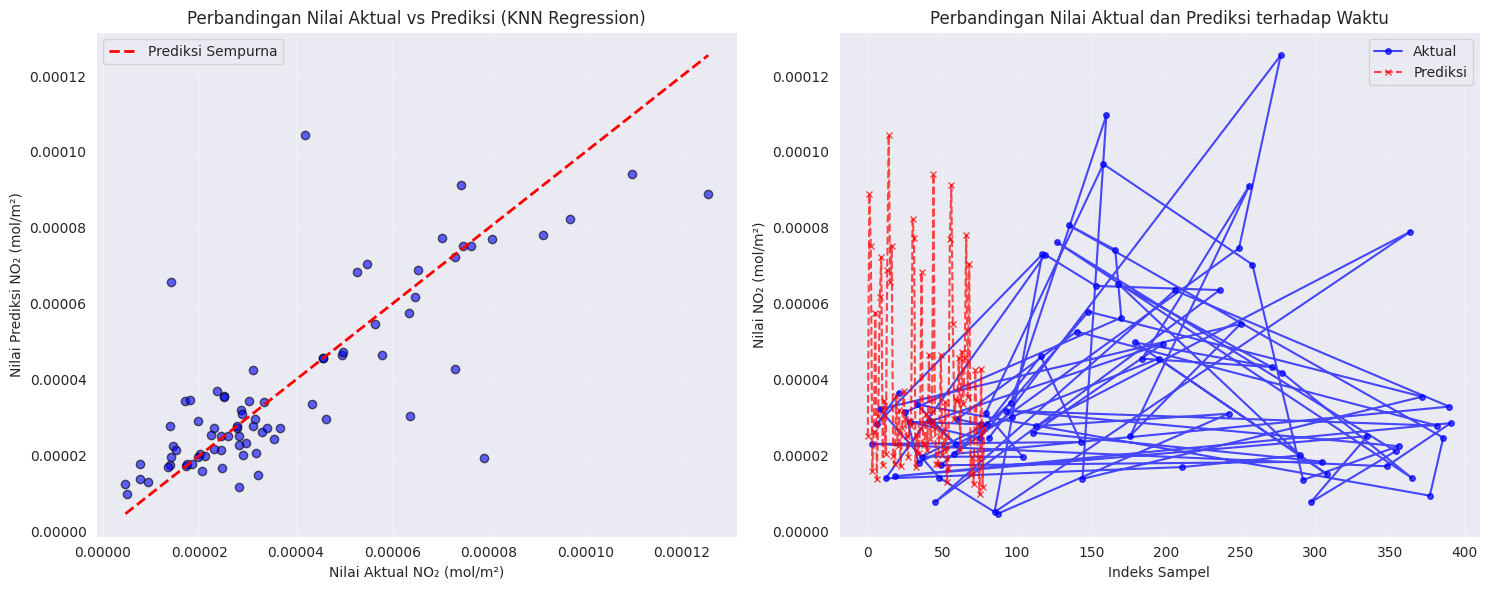

CONTOH PREDIKSI DATA BARU
Data input (lag t-1, t-2, t-3): [[0.45 0.42 0.5 ]]
Prediksi konsentrasi NO₂ (mol/m²): 0.00007151


In [10]:
# ========================== LANGKAH 9: VISUALISASI DAN ANALISIS PREDIKSI ==========================
print("=" * 80)
print("LANGKAH 9: VISUALISASI DAN ANALISIS PREDIKSI")
print("=" * 80)

import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Buat prediksi dengan model KNN akhir
y_pred_knn = knn_final.predict(X_test_scaled)

# 2️⃣ Hitung metrik evaluasi
mae = np.mean(np.abs(y_test - y_pred_knn))
rmse = np.sqrt(np.mean((y_test - y_pred_knn) ** 2))
r2 = knn_final.score(X_test_scaled, y_test)

print(f"Mean Absolute Error (MAE): {mae:.8f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.8f}")
print(f"R² Score: {r2:.8f}")
print("\nAnalisis selesai, lanjut ke visualisasi...\n")

# 3️⃣ Visualisasi: Scatter Plot dan Time Series
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs Predicted (Scatter Plot)
axes[0].scatter(y_test, y_pred_knn, alpha=0.6, color='blue', edgecolors='k')
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Prediksi Sempurna'
)
axes[0].set_xlabel('Nilai Aktual NO₂ (mol/m²)')
axes[0].set_ylabel('Nilai Prediksi NO₂ (mol/m²)')
axes[0].set_title('Perbandingan Nilai Aktual vs Prediksi (KNN Regression)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Time Series Comparison
axes[1].plot(y_test, 'o-', label='Aktual', color='blue', alpha=0.7, markersize=4)
axes[1].plot(y_pred_knn, 'x--', label='Prediksi', color='red', alpha=0.7, markersize=4)
axes[1].set_xlabel('Indeks Sampel')
axes[1].set_ylabel('Nilai NO₂ (mol/m²)')
axes[1].set_title('Perbandingan Nilai Aktual dan Prediksi terhadap Waktu')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4️⃣ Contoh prediksi baru (opsional)
print("=" * 80)
print("CONTOH PREDIKSI DATA BARU")
print("=" * 80)

# Misal data baru hasil normalisasi (lag t-1, t-2, t-3)
new_sample = np.array([[0.45, 0.42, 0.50]])  
predicted_no2 = knn_final.predict(new_sample)

print(f"Data input (lag t-1, t-2, t-3): {new_sample}")
print(f"Prediksi konsentrasi NO₂ (mol/m²): {predicted_no2[0]:.8f}")


### 10. Prediksi Nilai NO2 Satu Hari Ke Depan

LANGKAH 10: PREDIKSI NILAI NO₂ HARI BERIKUTNYA & EVALUASI TERHADAP STANDAR WHO

📅 Hasil Prediksi untuk Hari Berikutnya:
  • NO₂ (mol/m²) : 0.00002742
  • NO₂ (µg/m³)  : 1.26

🌍 Evaluasi terhadap Standar WHO:
  ✅ Konsentrasi masih dalam batas aman sesuai standar WHO


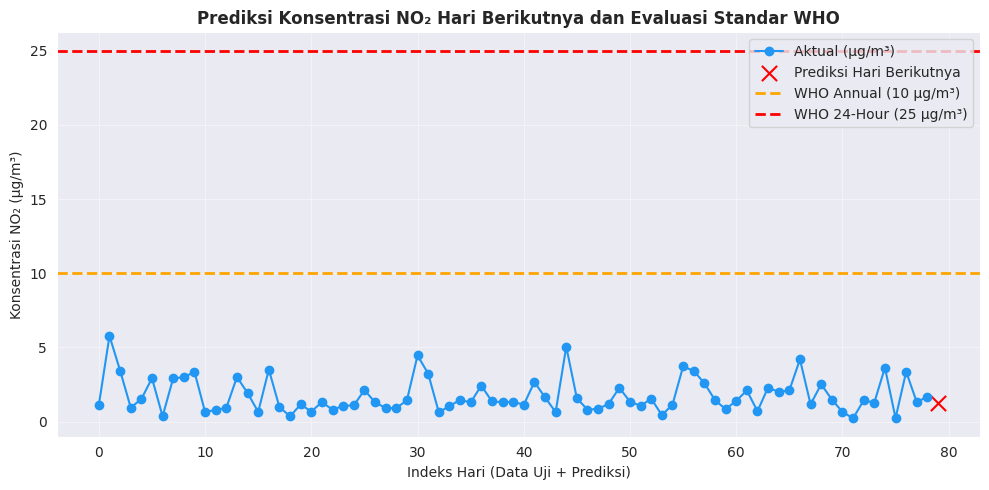

In [11]:
# ========================== LANGKAH 10: PREDIKSI NO₂ HARI BERIKUTNYA & EVALUASI WHO ==========================
print("=" * 90)
print("LANGKAH 10: PREDIKSI NILAI NO₂ HARI BERIKUTNYA & EVALUASI TERHADAP STANDAR WHO")
print("=" * 90)

import numpy as np
import matplotlib.pyplot as plt

# Pastikan model dan data sudah ada
# Model: knn_final
# Data: X_test_scaled, y_test

# Ambil data terakhir dari X_test_scaled untuk prediksi hari berikutnya
last_data = X_test_scaled[-1].reshape(1, -1)

# Prediksi nilai NO₂ untuk 1 hari ke depan (dalam satuan mol/m²)
predicted_next_day_mol = knn_final.predict(last_data)[0]

# Konversi ke µg/m³
CONVERSION_FACTOR = 46010
predicted_next_day_ugm3 = predicted_next_day_mol * CONVERSION_FACTOR

# Standar WHO
WHO_ANNUAL = 10     # µg/m³ (rata-rata tahunan)
WHO_24HOUR = 25     # µg/m³ (rata-rata harian)

print(f"\n📅 Hasil Prediksi untuk Hari Berikutnya:")
print(f"  • NO₂ (mol/m²) : {predicted_next_day_mol:.8f}")
print(f"  • NO₂ (µg/m³)  : {predicted_next_day_ugm3:.2f}")

# Evaluasi terhadap standar WHO
print("\n🌍 Evaluasi terhadap Standar WHO:")
if predicted_next_day_ugm3 > WHO_24HOUR:
    print(f"  ⚠️ Konsentrasi melebihi batas WHO 24 Jam ({WHO_24HOUR} µg/m³)")
elif predicted_next_day_ugm3 > WHO_ANNUAL:
    print(f"  ⚠️ Konsentrasi melebihi batas tahunan WHO ({WHO_ANNUAL} µg/m³) tapi masih di bawah 24 jam")
else:
    print("  ✅ Konsentrasi masih dalam batas aman sesuai standar WHO")

# ========================== VISUALISASI ==========================
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test * CONVERSION_FACTOR, 'o-', label='Aktual (µg/m³)', color='#2196F3')
plt.scatter(len(y_test), predicted_next_day_ugm3, color='red', s=120, marker='x', label='Prediksi Hari Berikutnya')

plt.axhline(WHO_ANNUAL, color='orange', linestyle='--', linewidth=2, label=f"WHO Annual ({WHO_ANNUAL} µg/m³)")
plt.axhline(WHO_24HOUR, color='red', linestyle='--', linewidth=2, label=f"WHO 24-Hour ({WHO_24HOUR} µg/m³)")

plt.title("Prediksi Konsentrasi NO₂ Hari Berikutnya dan Evaluasi Standar WHO", fontsize=12, fontweight="bold")
plt.xlabel("Indeks Hari (Data Uji + Prediksi)")
plt.ylabel("Konsentrasi NO₂ (µg/m³)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Implementasi Model - Deployment


DEPLOYMENT MODEL : PREDIKSI KONSENTRASI NO₂ DATA BARU

🔹 Simulasi prediksi dengan beberapa skenario:
1. Skenario 1 - Rendah → NO₂(t-3)=0.000015, NO₂(t-2)=0.000014, NO₂(t-1)=0.000013
2. Skenario 2 - Sedang → NO₂(t-3)=0.000020, NO₂(t-2)=0.000019, NO₂(t-1)=0.000019
3. Skenario 3 - Tinggi → NO₂(t-3)=0.000032, NO₂(t-2)=0.000031, NO₂(t-1)=0.000030

✅ Menggunakan Skenario 2 - Sedang
   Input data (mol/m²): [2.00e-05 1.95e-05 1.90e-05]

🔧 Scaler membutuhkan 3 fitur
🔹 Jumlah fitur input disesuaikan menjadi: 3 kolom

📈 HASIL PREDIKSI:
  • Prediksi NO₂ (mol/m²): 0.0000179249
  • Prediksi NO₂ (µg/m³): 0.82
  • Status WHO: SANGAT BAIK ✅


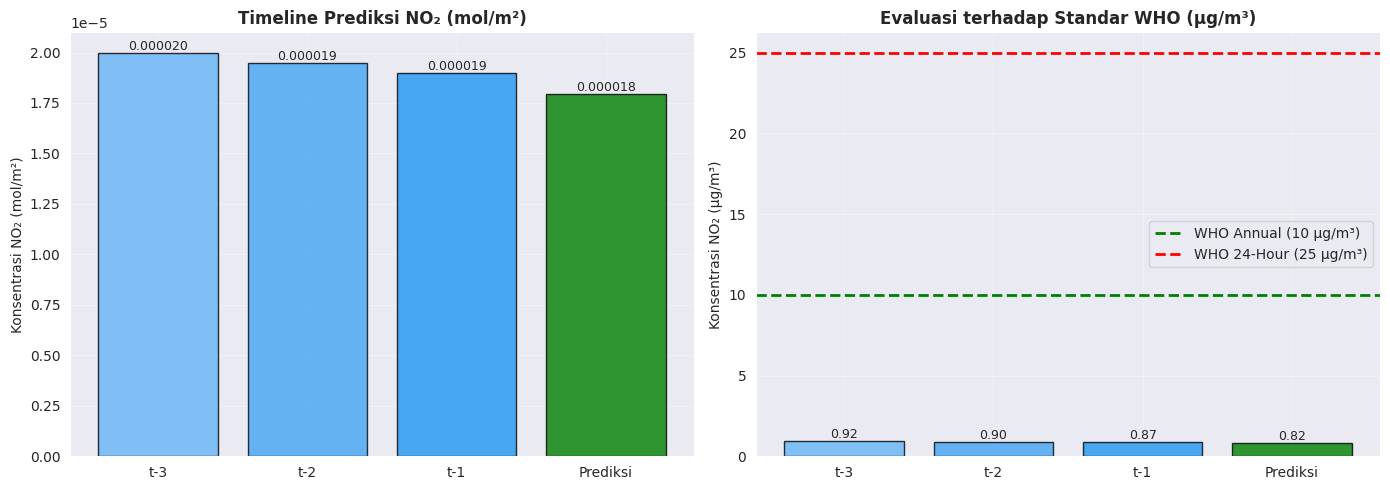


💾 Deployment selesai: Status kualitas udara = SANGAT BAIK ✅


In [16]:
# ========================== DEPLOYMENT - PREDIKSI DATA BARU ==========================
print("\n" + "=" * 80)
print("DEPLOYMENT MODEL : PREDIKSI KONSENTRASI NO₂ DATA BARU")
print("=" * 80)

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Parameter dan Konstanta WHO
# -----------------------------------------------
CONVERSION_FACTOR = 46010  # mol/m² → µg/m³
WHO_ANNUAL = 10
WHO_24HOUR = 25

# -----------------------------------------------
# 2️⃣ Data input baru (3 skenario uji)
# -----------------------------------------------
print("\n🔹 Simulasi prediksi dengan beberapa skenario:")

scenarios = {
    "Skenario 1 - Rendah": [1.5e-05, 1.4e-05, 1.3e-05],
    "Skenario 2 - Sedang": [2.0e-05, 1.95e-05, 1.9e-05],
    "Skenario 3 - Tinggi": [3.2e-05, 3.1e-05, 3.05e-05]
}

for i, (name, values) in enumerate(scenarios.items(), 1):
    print(f"{i}. {name} → NO₂(t-3)={values[0]:.6f}, NO₂(t-2)={values[1]:.6f}, NO₂(t-1)={values[2]:.6f}")

# Pilih salah satu skenario (bisa diubah manual)
selected_scenario = "Skenario 2 - Sedang"
data_input_raw = np.array([scenarios[selected_scenario]])

print(f"\n✅ Menggunakan {selected_scenario}")
print(f"   Input data (mol/m²): {data_input_raw.flatten()}")

# -----------------------------------------------
# 3️⃣ Load model & scaler
# -----------------------------------------------
scaler_deploy = joblib.load("scaler1.pkl")
model_deploy = joblib.load("model_knn_regression.pkl")

# -----------------------------------------------
# 4️⃣ Sesuaikan jumlah fitur input
# -----------------------------------------------
expected_features = scaler_deploy.n_features_in_
print(f"\n🔧 Scaler membutuhkan {expected_features} fitur")

# Jika model dilatih dengan lebih banyak fitur,
# tambahkan nilai 0 atau duplikasi fitur terakhir agar dimensi cocok
if data_input_raw.shape[1] < expected_features:
    padding = expected_features - data_input_raw.shape[1]
    data_input = np.hstack([data_input_raw, np.repeat(data_input_raw[:, -1], padding).reshape(1, -1)])
else:
    data_input = data_input_raw[:, :expected_features]

print(f"🔹 Jumlah fitur input disesuaikan menjadi: {data_input.shape[1]} kolom")

# -----------------------------------------------
# 5️⃣ Normalisasi dan Prediksi
# -----------------------------------------------
data_scaled = scaler_deploy.transform(data_input)
predicted_mol = model_deploy.predict(data_scaled)[0]
predicted_ugm3 = predicted_mol * CONVERSION_FACTOR

# -----------------------------------------------
# 6️⃣ Evaluasi terhadap standar WHO
# -----------------------------------------------
if predicted_ugm3 <= WHO_ANNUAL:
    status = "SANGAT BAIK ✅"
    color = "green"
elif predicted_ugm3 <= WHO_24HOUR:
    status = "PERHATIAN ⚠️"
    color = "orange"
else:
    status = "BERBAHAYA ❌"
    color = "red"

# -----------------------------------------------
# 7️⃣ Tampilkan hasil
# -----------------------------------------------
print("\n📈 HASIL PREDIKSI:")
print(f"  • Prediksi NO₂ (mol/m²): {predicted_mol:.10f}")
print(f"  • Prediksi NO₂ (µg/m³): {predicted_ugm3:.2f}")
print(f"  • Status WHO: {status}")

# -----------------------------------------------
# 8️⃣ Visualisasi hasil
# -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Timeline Prediksi (mol/m²) ===
x_labels = ["t-3", "t-2", "t-1", "Prediksi"]
values_mol = list(data_input_raw.flatten()) + [predicted_mol]
colors = ["#64B5F6", "#42A5F5", "#2196F3", color]

bars1 = axes[0].bar(x_labels, values_mol, color=colors, edgecolor="black", alpha=0.8)
axes[0].set_title("Timeline Prediksi NO₂ (mol/m²)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Konsentrasi NO₂ (mol/m²)")
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars1, values_mol):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.6f}", 
                 ha="center", va="bottom", fontsize=9)

# === Plot 2: Evaluasi WHO (µg/m³) ===
values_ugm3 = [v * CONVERSION_FACTOR for v in data_input_raw.flatten()] + [predicted_ugm3]
bars2 = axes[1].bar(x_labels, values_ugm3, color=colors, edgecolor="black", alpha=0.8)
axes[1].axhline(WHO_ANNUAL, color="green", linestyle="--", linewidth=2, label=f"WHO Annual ({WHO_ANNUAL} µg/m³)")
axes[1].axhline(WHO_24HOUR, color="red", linestyle="--", linewidth=2, label=f"WHO 24-Hour ({WHO_24HOUR} µg/m³)")
axes[1].set_title("Evaluasi terhadap Standar WHO (µg/m³)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Konsentrasi NO₂ (µg/m³)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for bar, val in zip(bars2, values_ugm3):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}", 
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n💾 Deployment selesai: Status kualitas udara = {status}")


### PREDIKSI 3 HARI KE DEPAN

PREDIKSI MULTI-HARI: 3 HARI KE DEPAN MENGGUNAKAN MODEL KNN REGRESSION
✓ Model dan Scaler berhasil dimuat untuk deployment multi-step.

Data awal (mol/m²): [2.00e-05 1.95e-05 1.90e-05]

📅 Hari ke-1:
  • Input: [2.00e-05 1.95e-05 1.90e-05]
  • Prediksi NO₂ (mol/m²): 0.0000179249
  • Prediksi NO₂ (µg/m³): 0.82

📅 Hari ke-2:
  • Input: [1.95000000e-05 1.90000000e-05 1.79249002e-05]
  • Prediksi NO₂ (mol/m²): 0.0000161714
  • Prediksi NO₂ (µg/m³): 0.74

📅 Hari ke-3:
  • Input: [1.90000000e-05 1.79249002e-05 1.61713621e-05]
  • Prediksi NO₂ (mol/m²): 0.0000181662
  • Prediksi NO₂ (µg/m³): 0.84


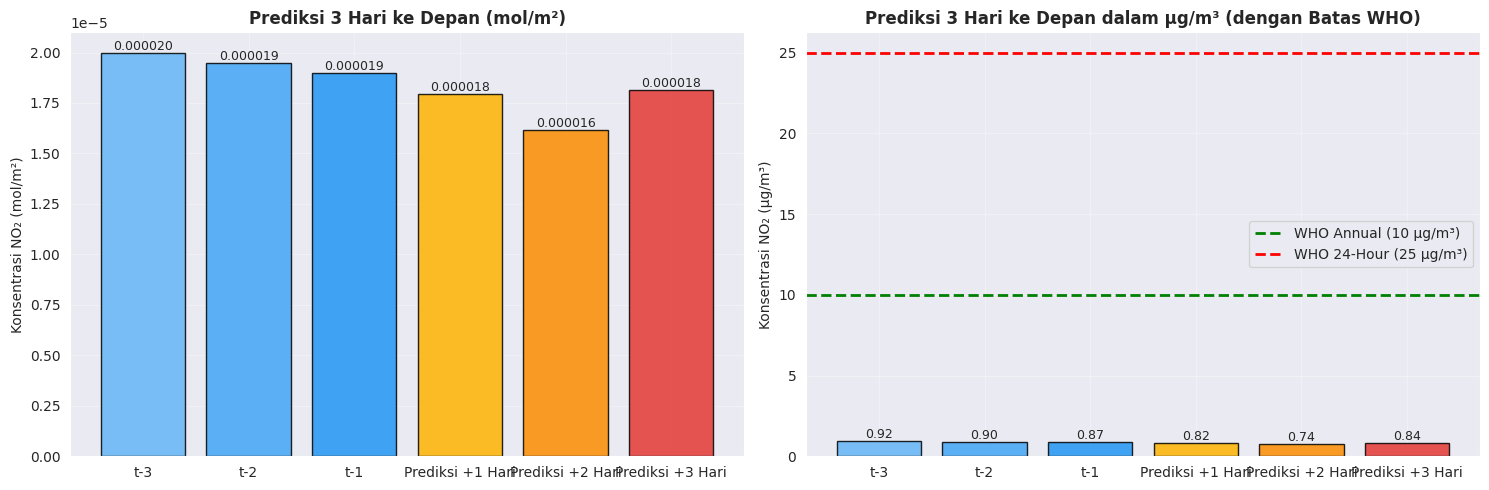


📊 RINGKASAN HASIL PREDIKSI MULTI-HARI:
  Hari ke-1: 0.0000179249 mol/m² (0.82 µg/m³) → SANGAT BAIK ✅
  Hari ke-2: 0.0000161714 mol/m² (0.74 µg/m³) → SANGAT BAIK ✅
  Hari ke-3: 0.0000181662 mol/m² (0.84 µg/m³) → SANGAT BAIK ✅

💾 Prediksi 3 hari ke depan selesai.


In [17]:
# ========================== LANGKAH PREDIKSI 3 HARI KE DEPAN ==========================
print("=" * 90)
print("PREDIKSI MULTI-HARI: 3 HARI KE DEPAN MENGGUNAKAN MODEL KNN REGRESSION")
print("=" * 90)

import numpy as np
import joblib
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Konstanta WHO dan faktor konversi
# -----------------------------------------------
CONVERSION_FACTOR = 46010  # mol/m² → µg/m³
WHO_ANNUAL = 10
WHO_24HOUR = 25

# -----------------------------------------------
# 2️⃣ Load model dan scaler tersimpan
# -----------------------------------------------
scaler_deploy = joblib.load("scaler1.pkl")
model_deploy = joblib.load("model_knn_regression.pkl")

print("✓ Model dan Scaler berhasil dimuat untuk deployment multi-step.\n")

# -----------------------------------------------
# 3️⃣ Data awal (misal dari 3 hari terakhir)
# -----------------------------------------------
recent_data = np.array([[2.0e-05, 1.95e-05, 1.9e-05]])  # [t-3, t-2, t-1]
print(f"Data awal (mol/m²): {recent_data.flatten()}")

# -----------------------------------------------
# 4️⃣ Prediksi hari ke-1 sampai ke-3
# -----------------------------------------------
predictions_mol = []
steps = 3  # jumlah hari ke depan (ubah dari 2 → 3)

current_input = recent_data.copy()

for step in range(1, steps + 1):
    # Normalisasi input
    scaled_input = scaler_deploy.transform(current_input)
    
    # Prediksi hari ke-n
    predicted_mol = model_deploy.predict(scaled_input)[0]
    predictions_mol.append(predicted_mol)
    
    print(f"\n📅 Hari ke-{step}:")
    print(f"  • Input: {current_input.flatten()}")
    print(f"  • Prediksi NO₂ (mol/m²): {predicted_mol:.10f}")
    print(f"  • Prediksi NO₂ (µg/m³): {predicted_mol * CONVERSION_FACTOR:.2f}")
    
    # Geser window: hapus nilai pertama, tambahkan prediksi baru
    new_input = np.append(current_input.flatten()[1:], predicted_mol).reshape(1, -1)
    current_input = new_input

# -----------------------------------------------
# 5️⃣ Konversi hasil prediksi ke µg/m³ dan analisis WHO
# -----------------------------------------------
predictions_ugm3 = np.array(predictions_mol) * CONVERSION_FACTOR

status_list = []
for val in predictions_ugm3:
    if val <= WHO_ANNUAL:
        status_list.append("SANGAT BAIK ✅")
    elif val <= WHO_24HOUR:
        status_list.append("PERHATIAN ⚠️")
    else:
        status_list.append("BERBAHAYA ❌")

# -----------------------------------------------
# 6️⃣ Visualisasi hasil prediksi multi-step
# -----------------------------------------------
x_labels = ["t-3", "t-2", "t-1", "Prediksi +1 Hari", "Prediksi +2 Hari", "Prediksi +3 Hari"]
values_mol = list(recent_data.flatten()) + predictions_mol
values_ugm3 = [v * CONVERSION_FACTOR for v in values_mol]

colors = ["#64B5F6", "#42A5F5", "#2196F3", "#FFB300", "#FB8C00", "#E53935"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Prediksi mol/m²
bars1 = axes[0].bar(x_labels, values_mol, color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("Prediksi 3 Hari ke Depan (mol/m²)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Konsentrasi NO₂ (mol/m²)")
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars1, values_mol):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.6f}", 
                 ha="center", va="bottom", fontsize=9)

# Plot 2: µg/m³ + Batas WHO
bars2 = axes[1].bar(x_labels, values_ugm3, color=colors, edgecolor="black", alpha=0.85)
axes[1].axhline(WHO_ANNUAL, color="green", linestyle="--", linewidth=2, label=f"WHO Annual ({WHO_ANNUAL} µg/m³)")
axes[1].axhline(WHO_24HOUR, color="red", linestyle="--", linewidth=2, label=f"WHO 24-Hour ({WHO_24HOUR} µg/m³)")
axes[1].set_title("Prediksi 3 Hari ke Depan dalam µg/m³ (dengan Batas WHO)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Konsentrasi NO₂ (µg/m³)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for bar, val in zip(bars2, values_ugm3):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}", 
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------------------------
# 7️⃣ Ringkasan hasil akhir
# -----------------------------------------------
print("\n📊 RINGKASAN HASIL PREDIKSI MULTI-HARI:")
for i, (mol, ugm3, status) in enumerate(zip(predictions_mol, predictions_ugm3, status_list), 1):
    print(f"  Hari ke-{i}: {mol:.10f} mol/m² ({ugm3:.2f} µg/m³) → {status}")

print("\n💾 Prediksi 3 hari ke depan selesai.")


#### Tampilan UI dari streamlit file app.py

In [ ]:
import streamlit as st

# ⚡ HARUS DI ATAS SEMUA COMPONENT STREAMLIT
st.set_page_config(page_title="Prediksi NO₂", layout="centered")

import pandas as pd
import numpy as np
import joblib
import matplotlib
matplotlib.use('Agg')  # Supaya matplotlib aman di server
import matplotlib.pyplot as plt

# ---------------------------
# Load model & scaler
# ---------------------------
@st.cache_resource
def load_model_scaler():
    model = joblib.load("model_knn_regression.pkl")
    scaler = joblib.load("scaler1.pkl")
    return model, scaler

model, scaler = load_model_scaler()

# ---------------------------
# Fungsi interpretasi
# ---------------------------
def interpret_no2(value):
    if value < 2e-5:
        return "Baik ✅", "green"
    elif value < 3e-5:
        return "Sedang ⚠️", "orange"
    else:
        return "Buruk ❌", "red"

# ---------------------------
# Load data CSV
# ---------------------------
try:
    df = pd.read_csv("timeseries.csv")
    df['NO2'] = df['NO2'].astype(float)
except:
    df = None

# ---------------------------
# Header aplikasi
# ---------------------------
st.markdown(
    """
    <div style="text-align:center">
        <h1>🌬️ Prediksi NO₂ Menggunakan KNN Regression</h1>
        <p>Masukkan tiga nilai NO₂ terakhir untuk memprediksi NO₂ hari ini.</p>
    </div>
    """, unsafe_allow_html=True
)

# ---------------------------
# Input nilai NO2
# ---------------------------
col1, col2, col3 = st.columns(3)
t3_default = float(df['NO2'].values[-3]) if df is not None and len(df) >= 3 else 0.0
t2_default = float(df['NO2'].values[-2]) if df is not None and len(df) >= 2 else 0.0
t1_default = float(df['NO2'].values[-1]) if df is not None and len(df) >= 1 else 0.0

with col1:
    t3 = st.number_input("NO₂(t-3)", value=t3_default, format="%.8f")
with col2:
    t2 = st.number_input("NO₂(t-2)", value=t2_default, format="%.8f")
with col3:
    t1 = st.number_input("NO₂(t-1)", value=t1_default, format="%.8f")

# ---------------------------
# Tombol prediksi
# ---------------------------
if st.button("Prediksi NO₂"):
    data_input = np.array([t3, t2, t1]).reshape(1, -1)
    data_scaled = scaler.transform(data_input)
    pred_value = model.predict(data_scaled)[0]
    keterangan, color = interpret_no2(pred_value)

    st.markdown(f"### Hasil Prediksi: **{pred_value:.8f}**")
    st.markdown(f"<h4 style='color:{color}'>Keterangan kualitas udara: {keterangan}</h4>", unsafe_allow_html=True)

    # ---------------------------
    # Plot tren NO2
    # ---------------------------
    if df is not None and len(df) >= 3:
        fig, ax = plt.subplots(figsize=(8,4))
        ax.plot(df.index, df['NO2'], label='NO₂ harian', marker='o')
        ax.plot(df.index[-3:], df['NO2'].values[-3:], color='red', marker='o', linestyle='', label='3 hari terakhir')
        ax.scatter(df.index[-1]+1, pred_value, color=color, s=100, label='Prediksi')
        ax.set_xlabel("Hari")
        ax.set_ylabel("NO₂ (ppm)")
        ax.set_title("Tren NO₂ Harian")
        ax.legend()
        st.pyplot(fig)


#### Link web streamlit
- https://fjbdfufrxqrxl9tjgsz4nb.streamlit.app/

#### 